In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time
import torch

CONFIG_A = {
      'n': 3, 'T': 5, 'r': 0.03, 'A': 0.5,
      'a_k': [0.08, 0.06, 0.10],
      's_k': [0.02, 0.015, 0.04],
      'p_init': [0.25, 0.25, 0.25, 0.25],
}

CONFIG_B = {
    'n': 4, 'T': 5, 'r': 0.03, 'A': 0.5,
    'a_k': [0.08, 0.06, 0.10, 0.07],
    's_k': [0.02, 0.015, 0.04, 0.025],
    'p_init': [0.20, 0.20, 0.20, 0.20, 0.20],
}

def utility(W, A=0.5):
    return (1 - np.exp(-A*np.clip(W, -20, 100))) / A

In [3]:
def simulate_hold(cfg, num_episodes=2000, seed=42):
    n, T, r, A = cfg['n'], cfg['T'], cfg['r'], cfg['A']
    a_k = np.array(cfg['a_k'])
    std_k = np.sqrt(np.array(cfg['s_k']))
    p_init = np.array(cfg['p_init'])

    np.random.seed(seed)
    wealth_paths = np.zeros((num_episodes, T + 1))
    alloc_history = np.zeros((num_episodes, T, n + 1))
    terminal_wealths = np.zeros(num_episodes)

    for ep in range(num_episodes):
        W = 1.0
        p = p_init.copy()
        wealth_paths[ep, 0] = W

        for t in range(T):
            alloc_history[ep, t] = p
            R = np.random.normal(a_k, std_k)
            port_ret = p[0] * r + (p[1:] * R).sum()
            W_new = W * (1.0 + port_ret)

            if W_new <= 0.001:
                W = 0.001
                p = np.concatenate([[1.0], np.zeros(n)])
            else:
                denom = 1.0 + port_ret
                p = np.concatenate([[p[0] * (1 + r) / denom],
                                     p[1:] * (1 + R) / denom])
                W = W_new
            wealth_paths[ep, t + 1] = W

        terminal_wealths[ep] = W

    utils = utility(terminal_wealths, A)
    return {
        'avg_utility': np.mean(utils),
        'std_err': np.std(utils) / np.sqrt(num_episodes),
        'avg_wealth': np.mean(terminal_wealths),
        'med_wealth': np.median(terminal_wealths),
        'wealth_paths': wealth_paths,
        'terminal_wealths': terminal_wealths,
        'alloc_history': alloc_history,
    }

In [4]:
def simulate_with_tracking(get_action, cfg, leverage_factor=1.0, num_episodes=2000, seed=42):
    """Generic forward simulation with wealth + allocation tracking.
    get_action(t, W, p_risky) -> action array of shape (n,)
    """
    n, T, r, A = cfg['n'], cfg['T'], cfg['r'], cfg['A']
    a_k = np.array(cfg['a_k'])
    std_k = np.sqrt(np.array(cfg['s_k']))
    p_init = np.array(cfg['p_init'])

    np.random.seed(seed)
    wealth_paths = np.zeros((num_episodes, T + 1))
    alloc_history = np.zeros((num_episodes, T, n + 1))
    terminal_wealths = np.zeros(num_episodes)

    for ep in range(num_episodes):
        W = 1.0
        p = p_init.copy()
        wealth_paths[ep, 0] = W

        for t in range(T):
            p_risky = p[1:].copy()
            action = get_action(t, W, p_risky)

            new_pr = p_risky + action
            new_cash = 1.0 - new_pr.sum()

            # Enforce leverage constraint
            max_lev = 1.0 + leverage_factor * max(W, 0.0)
            gross = np.abs(new_cash) + np.abs(new_pr).sum()
            if gross > max_lev + 1e-10:
                scale = max_lev / gross
                new_pr = p_risky + action * scale
                new_cash = 1.0 - new_pr.sum()

            alloc_history[ep, t] = np.concatenate([[new_cash], new_pr])

            R = np.random.normal(a_k, std_k)
            port_ret = new_cash * r + (new_pr * R).sum()
            W_new = W * (1.0 + port_ret)

            if W_new <= 0.001:
                W = 0.001
                p = np.concatenate([[1.0], np.zeros(n)])
            else:
                denom = 1.0 + port_ret
                p = np.concatenate([[new_cash * (1 + r) / denom],
                                     new_pr * (1 + R) / denom])
                W = W_new
            wealth_paths[ep, t + 1] = W

        terminal_wealths[ep] = W

    utils = utility(terminal_wealths, A)
    return {
        'avg_utility': np.mean(utils),
        'std_err': np.std(utils) / np.sqrt(num_episodes),
        'avg_wealth': np.mean(terminal_wealths),
        'med_wealth': np.median(terminal_wealths),
        'wealth_paths': wealth_paths,
        'terminal_wealths': terminal_wealths,
        'alloc_history': alloc_history,
    }


def run_tabular(cfg, num_episodes=2000, seed=42):
    from backward import solve_dp
    n = cfg['n']

    print("Solving Tabular DP...")
    t0 = time.time()
    v_grids, policy, config = solve_dp(
        n=n, T=cfg['T'], r=cfg['r'], A=cfg['A'],
        a_k=list(cfg['a_k']), s_k=list(cfg['s_k']),
        prop_min=0.0, prop_max=1.0, prop_step=0.25,
        leverage_factor=1.0,
    )
    print(f"Solved in {time.time()-t0:.1f}s")

    w_grid = config['w_grid']
    p_single_grid = config['p_single_grid']

    def get_action(t, W, p_risky):
        wi = int(np.argmin(np.abs(w_grid - W)))
        pidx = tuple(int(np.argmin(np.abs(p_single_grid - p_risky[k]))) for k in range(n))
        return policy[t][(wi,) + pidx].copy()

    return simulate_with_tracking(get_action, cfg, leverage_factor=1.0,
                                   num_episodes=num_episodes, seed=seed)


def run_adp(cfg, num_episodes=2000, seed=42):
    from backward_adp import solve_dp as solve_adp
    n = cfg['n']
    p_init_risky = list(np.array(cfg['p_init'])[1:])

    print("Solving ADP...")
    t0 = time.time()
    v_nets, policy_nets, config = solve_adp(
        n=n, T=cfg['T'], r=cfg['r'], A=cfg['A'],
        a_k=list(cfg['a_k']), s_k=list(cfg['s_k']),
        prop_min=0.0, prop_max=1.0,
        leverage_factor=1.0,
        hidden_size=128, n_train=5000, epochs=200, lr=1e-3,
        p_init_risky=p_init_risky,
    )
    print(f"Solved in {time.time()-t0:.1f}s")

    action_max = config['action_max']

    def get_action(t, W, p_risky):
        state = np.concatenate([[W], p_risky])
        state_t = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
            action = policy_nets[t](state_t).squeeze(0).numpy()
        return action * action_max

    return simulate_with_tracking(get_action, cfg, leverage_factor=1.0,
                                   num_episodes=num_episodes, seed=seed)


def run_ppo(cfg, num_episodes=2000, seed=42, timesteps=500_000):
    from stock_price_simulations import ConstrainedMultiAssetEnv
    from stable_baselines3 import PPO
    n, T, A = cfg['n'], cfg['T'], cfg['A']

    env = ConstrainedMultiAssetEnv(
        n=n, T=T, r=cfg['r'], A=A,
        a_k=list(cfg['a_k']), s_k=list(cfg['s_k']),
        p_init=list(cfg['p_init']),
    )

    print("Training PPO...")
    t0 = time.time()
    model = PPO("MlpPolicy", env, verbose=0, learning_rate=0.001)
    model.learn(total_timesteps=timesteps)
    print(f"Trained in {time.time()-t0:.1f}s")

    wealth_paths = np.zeros((num_episodes, T + 1))
    alloc_history = np.zeros((num_episodes, T, n + 1))
    terminal_wealths = np.zeros(num_episodes)

    np.random.seed(seed)
    for ep in range(num_episodes):
        obs, _ = env.reset()
        wealth_paths[ep, 0] = env.wealth
        for t in range(T):
            alloc_history[ep, t] = env.p.copy()
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, _, _ = env.step(action)
            wealth_paths[ep, t + 1] = env.wealth
        terminal_wealths[ep] = env.wealth

    utils = utility(terminal_wealths, A)
    return {
        'avg_utility': np.mean(utils),
        'std_err': np.std(utils) / np.sqrt(num_episodes),
        'avg_wealth': np.mean(terminal_wealths),
        'med_wealth': np.median(terminal_wealths),
        'wealth_paths': wealth_paths,
        'terminal_wealths': terminal_wealths,
        'alloc_history': alloc_history,
    }

In [5]:
print("=== Config A: n=3, T=5 ===\n")
results_A = {}

results_A['Hold'] = simulate_hold(CONFIG_A)
print(f"Hold done: utility={results_A['Hold']['avg_utility']:.5f}")

results_A['PPO'] = run_ppo(CONFIG_A)
print(f"PPO done: utility={results_A['PPO']['avg_utility']:.5f}")

results_A['Tabular DP'] = run_tabular(CONFIG_A)
print(f"Tabular DP done: utility={results_A['Tabular DP']['avg_utility']:.5f}")

results_A['ADP'] = run_adp(CONFIG_A)
print(f"ADP done: utility={results_A['ADP']['avg_utility']:.5f}")

=== Config A: n=3, T=5 ===

Hold done: utility=0.99790
Training PPO...
Trained in 218.8s
PPO done: utility=1.03494
Solving Tabular DP...
Setup: n=3, T=5, r=0.03, A=0.5
  Mean returns:   [np.float64(0.08), np.float64(0.06), np.float64(0.1)]
  Excess returns: [np.float64(0.05), np.float64(0.03), np.float64(0.07)]
  Wealth grid: 15 pts in [0.05, 3.5]
  Prop grid: 5 pts in [0.0, 1.0], step=0.25
  Prop combos: 125
  Actions: 55 feasible
  Quadrature: 5^3 = 125 points

Backward Induction
  t=4: 1,629 states, 7.7s
  t=3: 1,629 states, 7.9s
  t=2: 1,629 states, 8.8s
  t=1: 1,629 states, 7.8s
  t=0: 1,629 states, 7.9s

Total solve time: 40.1s
Solved in 40.1s
Tabular DP done: utility=1.04821
Solving ADP...
ADP Setup: n=3, T=5, r=0.03, A=0.5
  Mean returns:   [np.float64(0.08), np.float64(0.06), np.float64(0.1)]
  Excess returns: [np.float64(0.05), np.float64(0.03), np.float64(0.07)]
  Training samples per step: 5000
  Actions: 55 feasible
  Quadrature: 5^3 = 125 points
  NN: hidden_size=128, epo

In [6]:
print("=== Config B: n=4, T=5 ===\n")
results_B = {}

results_B['Hold'] = simulate_hold(CONFIG_B)
print(f"Hold done: utility={results_B['Hold']['avg_utility']:.5f}")

results_B['PPO'] = run_ppo(CONFIG_B)
print(f"PPO done: utility={results_B['PPO']['avg_utility']:.5f}")

results_B['Tabular DP'] = run_tabular(CONFIG_B)
print(f"Tabular DP done: utility={results_B['Tabular DP']['avg_utility']:.5f}")

results_B['ADP'] = run_adp(CONFIG_B)
print(f"ADP done: utility={results_B['ADP']['avg_utility']:.5f}")

=== Config B: n=4, T=5 ===

Hold done: utility=0.99809
Training PPO...
Trained in 197.6s
PPO done: utility=1.03254
Solving Tabular DP...
Setup: n=4, T=5, r=0.03, A=0.5
  Mean returns:   [np.float64(0.08), np.float64(0.06), np.float64(0.1), np.float64(0.07)]
  Excess returns: [np.float64(0.05), np.float64(0.03), np.float64(0.07), np.float64(0.04)]
  Wealth grid: 15 pts in [0.05, 3.5]
  Prop grid: 5 pts in [0.0, 1.0], step=0.25
  Prop combos: 625
  Actions: 131 feasible
  Quadrature: 5^4 = 625 points

Backward Induction
  t=4: 6,406 states, 200.2s
  t=3: 6,406 states, 209.1s
  t=2: 6,406 states, 202.5s
  t=1: 6,406 states, 205.8s
  t=0: 6,406 states, 207.7s

Total solve time: 1025.2s
Solved in 1025.2s
Tabular DP done: utility=1.04162
Solving ADP...
ADP Setup: n=4, T=5, r=0.03, A=0.5
  Mean returns:   [np.float64(0.08), np.float64(0.06), np.float64(0.1), np.float64(0.07)]
  Excess returns: [np.float64(0.05), np.float64(0.03), np.float64(0.07), np.float64(0.04)]
  Training samples per step

In [7]:
def print_table(label, results):
    print(f"\n{'='*70}")
    print(f"  {label}")
    print(f"{'='*70}")
    print(f"  {'Method':<14} {'Avg Utility':>12} {'± SE':>10} {'Avg Wealth':>12} {'Med Wealth':>12}")
    print(f"  {'-'*60}")
    for name, res in results.items():
        print(f"  {name:<14} {res['avg_utility']:>12.5f} {res['std_err']:>10.5f} "
              f"{res['avg_wealth']:>12.4f} {res['med_wealth']:>12.4f}")

print_table("Config A: n=3, T=5", results_A)
print_table("Config B: n=4, T=5", results_B)


  Config A: n=3, T=5
  Method          Avg Utility       ± SE   Avg Wealth   Med Wealth
  ------------------------------------------------------------
  Hold                0.99790    0.00235       1.3935       1.3732
  PPO                 1.03494    0.00318       1.4803       1.4498
  Tabular DP          1.04821    0.00384       1.5199       1.4622
  ADP                 1.05088    0.00377       1.5246       1.4676

  Config B: n=4, T=5
  Method          Avg Utility       ± SE   Avg Wealth   Med Wealth
  ------------------------------------------------------------
  Hold                0.99809    0.00214       1.3918       1.3787
  PPO                 1.03254    0.00289       1.4711       1.4436
  Tabular DP          1.04162    0.00362       1.5018       1.4587
  ADP                 1.05427    0.00369       1.5306       1.4860


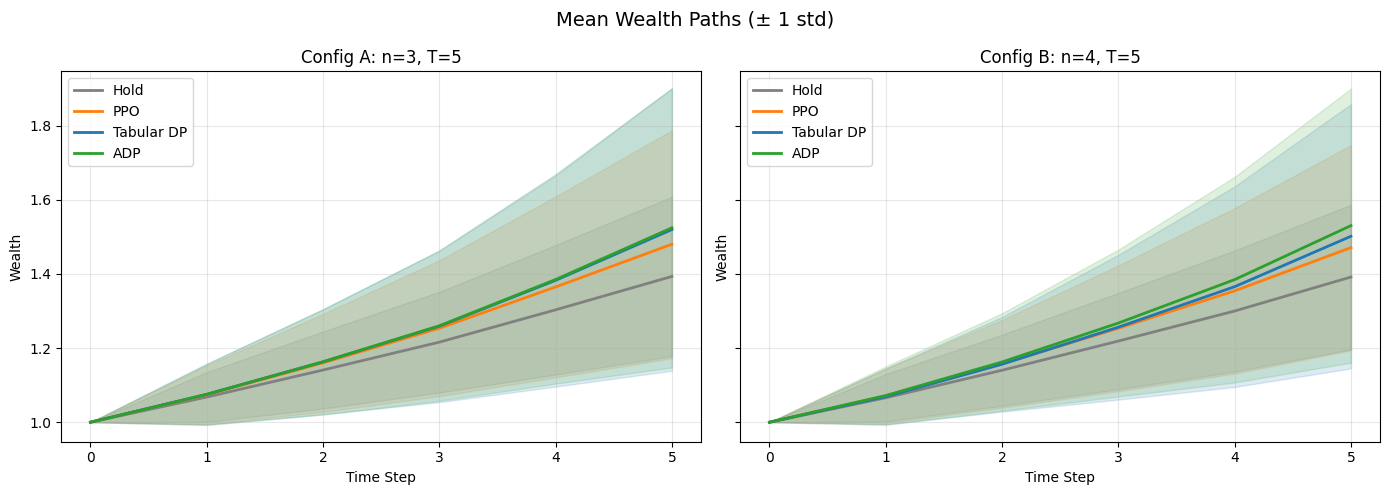

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
colors = {'Hold': 'gray', 'PPO': 'tab:orange', 'Tabular DP': 'tab:blue', 'ADP': 'tab:green'}

for ax, (label, results) in zip(axes, [("Config A: n=3, T=5", results_A),
                                         ("Config B: n=4, T=5", results_B)]):
    T = results['Hold']['wealth_paths'].shape[1] - 1
    ts = np.arange(T + 1)
    for name, res in results.items():
        wp = res['wealth_paths']
        mean = wp.mean(axis=0)
        std = wp.std(axis=0)
        ax.plot(ts, mean, label=name, color=colors[name], linewidth=2)
        ax.fill_between(ts, mean - std, mean + std, color=colors[name], alpha=0.15)
    ax.set_title(label)
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Wealth")
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle("Mean Wealth Paths (± 1 std)", fontsize=14)
plt.tight_layout()
plt.show()

/var/folders/88/r4q_2dj522v0clm2xr8nmq5h0000gn/T/ipykernel_73790/1868201954.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=methods, patch_artist=True, showfliers=False)
/var/folders/88/r4q_2dj522v0clm2xr8nmq5h0000gn/T/ipykernel_73790/1868201954.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=methods, patch_artist=True, showfliers=False)


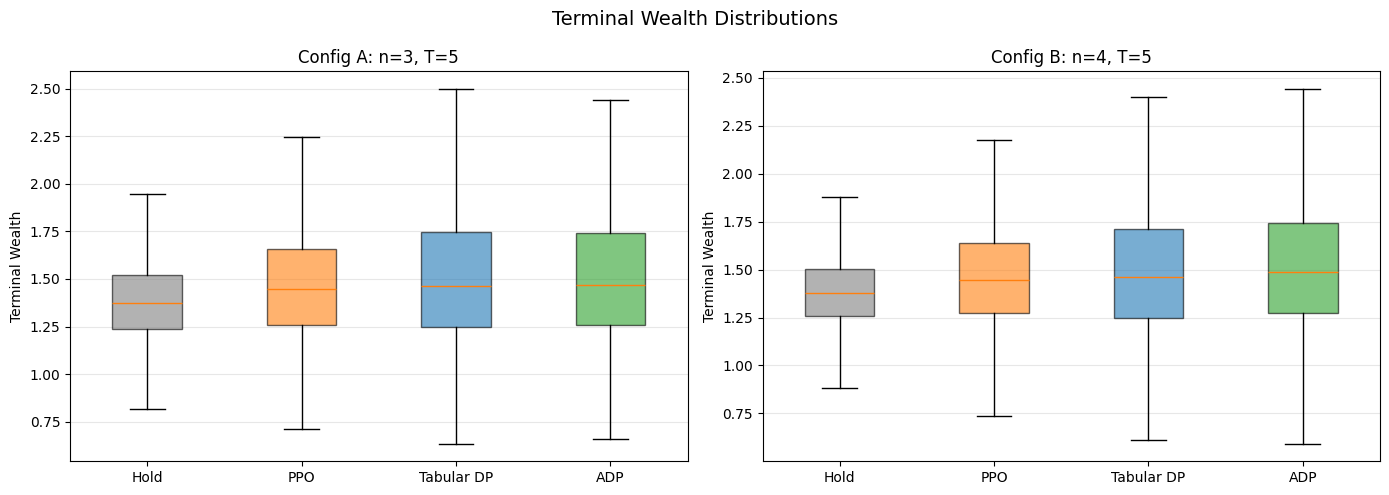

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
methods = ['Hold', 'PPO', 'Tabular DP', 'ADP']

for ax, (label, results) in zip(axes, [("Config A: n=3, T=5", results_A),
                                         ("Config B: n=4, T=5", results_B)]):
    data = [results[m]['terminal_wealths'] for m in methods]
    bp = ax.boxplot(data, labels=methods, patch_artist=True, showfliers=False)
    for patch, m in zip(bp['boxes'], methods):
        patch.set_facecolor(colors[m])
        patch.set_alpha(0.6)
    ax.set_title(label)
    ax.set_ylabel("Terminal Wealth")
    ax.grid(True, alpha=0.3, axis='y')

fig.suptitle("Terminal Wealth Distributions", fontsize=14)
plt.tight_layout()
plt.show()

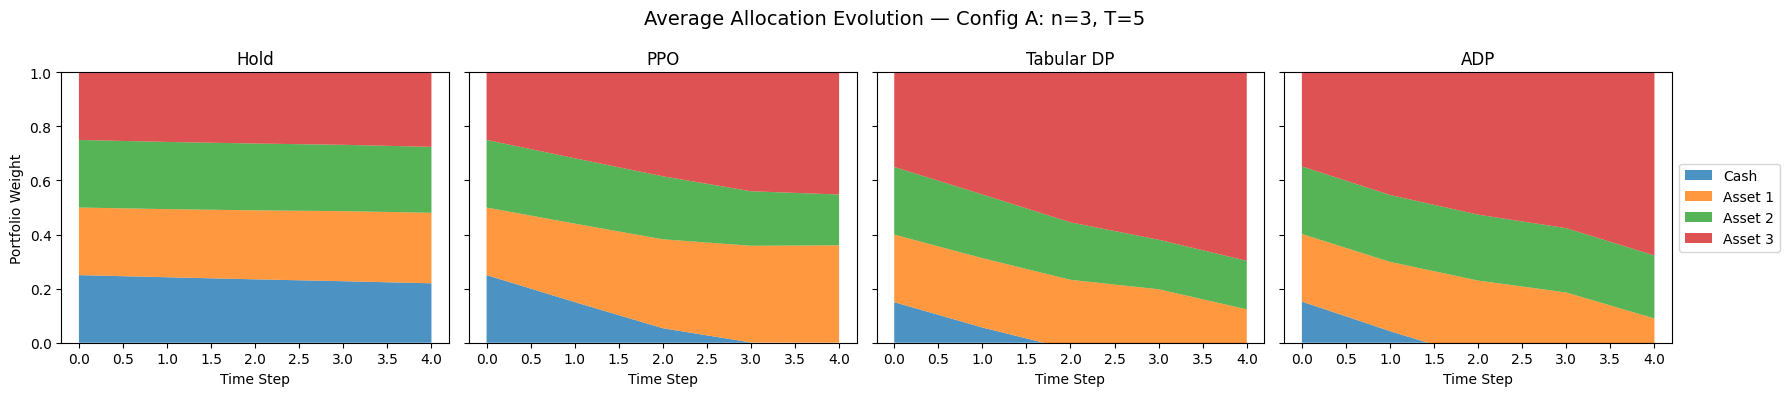

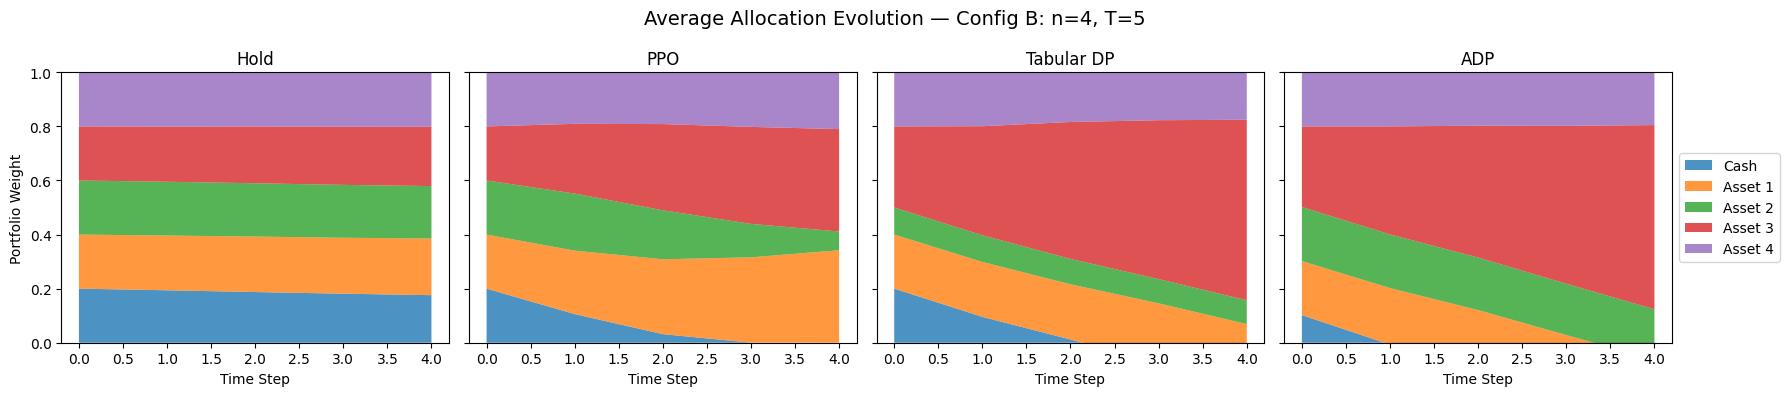

In [10]:
for cfg_label, results, cfg in [("Config A: n=3, T=5", results_A, CONFIG_A),
                                 ("Config B: n=4, T=5", results_B, CONFIG_B)]:
    n = cfg['n']
    T = cfg['T']
    fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
    asset_labels = ['Cash'] + [f'Asset {k+1}' for k in range(n)]

    for ax, method in zip(axes, methods):
        avg_alloc = results[method]['alloc_history'].mean(axis=0)  # (T, n+1)
        ax.stackplot(range(T), avg_alloc.T, labels=asset_labels, alpha=0.8)
        ax.set_title(method)
        ax.set_xlabel("Time Step")
        ax.set_ylim(0, 1)
        if ax == axes[0]:
            ax.set_ylabel("Portfolio Weight")

    axes[-1].legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
    fig.suptitle(f"Average Allocation Evolution — {cfg_label}", fontsize=14)
    plt.tight_layout()
    plt.show()

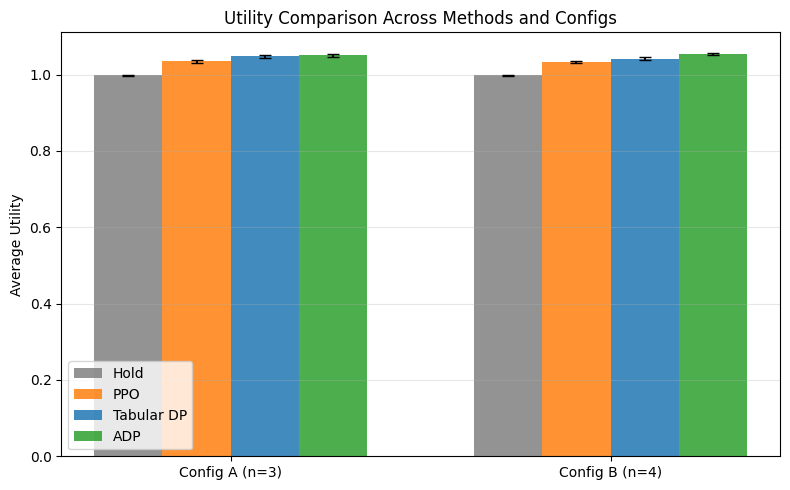

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(2)
width = 0.18

for i, method in enumerate(methods):
    vals = [results_A[method]['avg_utility'], results_B[method]['avg_utility']]
    errs = [results_A[method]['std_err'], results_B[method]['std_err']]
    ax.bar(x + i * width, vals, width, yerr=errs, label=method,
           color=colors[method], capsize=4, alpha=0.85)

ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(["Config A (n=3)", "Config B (n=4)"])
ax.set_ylabel("Average Utility")
ax.set_title("Utility Comparison Across Methods and Configs")
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()